In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# data from https://docs.google.com/spreadsheets/d/153dD9439q4jWMJDFFGjiI4Ez-WNmv3HbYQEq2_FjwtA/edit as of 12/9/25

data = [
    # Bush 1
    [1, 1, 1, 4.94, 915], [1, 1, 2, 4.4, 800], [1, 1, 3, 5.3, 680],
    [1, 2, 1, 10.9, 885], [1, 2, 2, 10.4, 795], [1, 2, 3, 12.7, 670],
    [1, 3, 1, 13.7, 860], [1, 3, 2, 18.2, 765], [1, 3, 3, 20.8, 655],
    
    # Bush 2  
    [2, 1, 1, 4.4, 930], [2, 1, 2, 6.7, 820], [2, 1, 3, 6.8, 715],
    [2, 2, 1, 9.7, 890], [2, 2, 2, 10, 800], [2, 2, 3, 15, 715],
    [2, 3, 1, 15.3, 905], [2, 3, 2, 15.9, 820], [2, 3, 3, 16, 705],
    
    # Bush 3
    [3, 1, 1, 6.2, 895], [3, 1, 2, 7.1, 800], [3, 1, 3, 9.1, 700],
    [3, 2, 1, 8.7, 745], [3, 2, 2, 9.4, 795], [3, 2, 3, 10.2, 700],
    [3, 3, 1, 13.5, 785], [3, 3, 2, 14.3, 710], [3, 3, 3, 14.1, 650],
    
    # Bush 4
    [4, 1, 1, 4.7, 840], [4, 1, 2, 4.9, 730], [4, 1, 3, 5, 625],
    [4, 2, 1, 9.8, 730], [4, 2, 2, 12.6, 660], [4, 2, 3, 12.3, 640],
    [4, 3, 1, 11.7, 800], [4, 3, 2, 12.6, 750], [4, 3, 3, 13.6, 650],
    
    # Bush 5
    [5, 1, 1, 7.7, 835], [5, 1, 2, 7.3, 765], [5, 1, 3, 7.9, 685],
    [5, 2, 1, 5.8, 905], [5, 2, 2, 9.3, 760], [5, 2, 3, 10.5, 675],
    [5, 3, 1, 16.1, 1085], [5, 3, 2, 18, 900], [5, 3, 3, 22.6, 690],
    
    # Bush 6
    [6, 1, 1, 8.5, 635], [6, 1, 2, 12.8, 645], [6, 1, 3, 12.4, 560],
    [6, 2, 1, 11.9, 840], [6, 2, 2, 12.3, 725], [6, 2, 3, 12.3, 590],
    [6, 3, 1, 11.7, 735], [6, 3, 2, 11.8, 720], [6, 3, 3, 12.3, 595]
]

# Create DataFrame
diamdata = pd.DataFrame(data, columns=['Bush', 'Branch', 'Location', 'Diameter', 'Height'])

In [ ]:
# save to CSV
# diamdata.to_csv('../data/diameters/branch_diameter_data.csv', index=False)

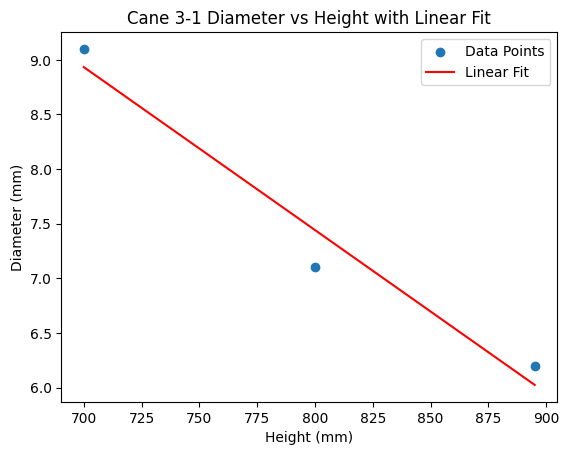

Cane 3-1 Linear Fit Coefficients (Diameter = m*Height + b): [-1.49167397e-02  1.93751972e+01]


In [16]:
bush_31_data = diamdata.query('Bush == 3 and Branch == 1')
cane_31_linearfit = np.polyfit(bush_31_data['Height'], bush_31_data['Diameter'], 1)
# plot the data and the linear fit
plt.scatter(bush_31_data['Height'], bush_31_data['Diameter'], label='Data Points')
plt.plot(bush_31_data['Height'], np.polyval(cane_31_linearfit, bush_31_data['Height']), color='red', label='Linear Fit')
plt.xlabel('Height (mm)')
plt.ylabel('Diameter (mm)')
plt.title('Cane 3-1 Diameter vs Height with Linear Fit')
plt.legend()
plt.show()
print("Cane 3-1 Linear Fit Coefficients (Diameter = m*Height + b):", cane_31_linearfit)

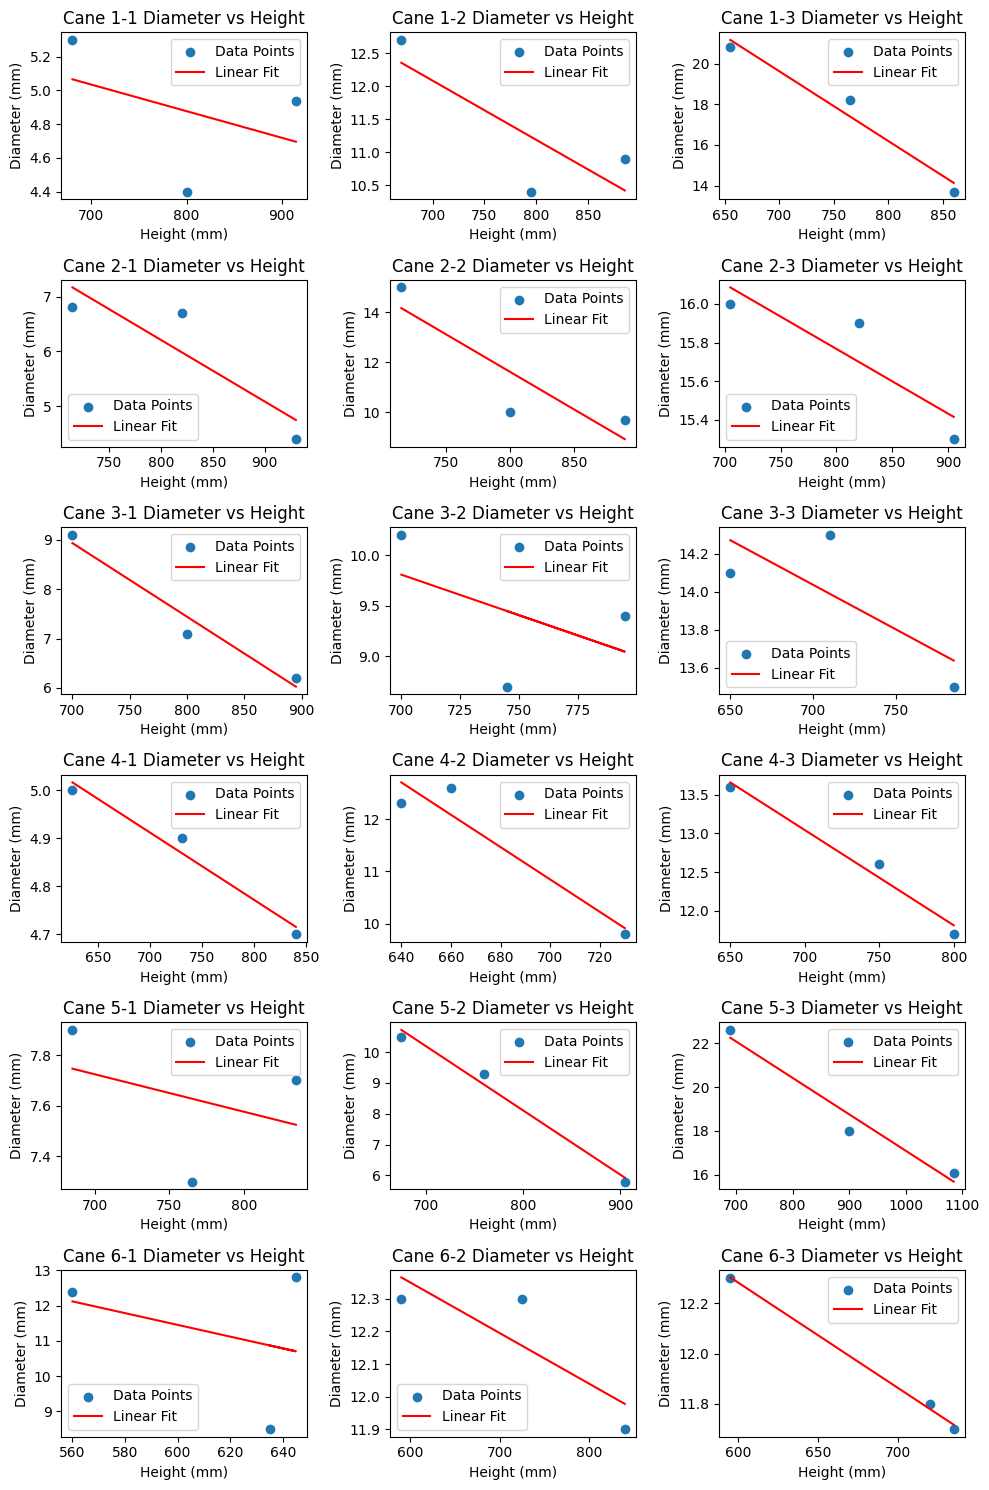

In [23]:
# Do the same for all the canes and plot all 27 in a grid of subplots
fig, axs = plt.subplots(6, 3, figsize=(10, 15))
for bush in range(1, 7):
    for branch in range(1, 4):
        ax = axs[bush-1, branch-1]
        cane_data = diamdata.query(f'Bush == {bush} and Branch == {branch}')
        linearfit = np.polyfit(cane_data['Height'], cane_data['Diameter'], 1)
        ax.scatter(cane_data['Height'], cane_data['Diameter'], label='Data Points')
        ax.plot(cane_data['Height'], np.polyval(linearfit, cane_data['Height']), color='red', label='Linear Fit')
        ax.set_xlabel('Height (mm)')
        ax.set_ylabel('Diameter (mm)')
        ax.set_title(f'Cane {bush}-{branch} Diameter vs Height')
        ax.legend()
plt.tight_layout()
plt.show()